In [8]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

from boulder_statistics.analysis.quick_calculate_PowerLaw import PowerLawFittingFunction
from boulder_statistics.analysis.quick_calculate_Weibull import WeibullFittingFunction
from boulder_statistics.analysis.quick_calculate_LogNormal import LogNormalFittingFunction

from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams
from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams

from statsmodels.base.model import GenericLikelihoodModelResults

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:156: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params))


Optimization terminated successfully.
         Current function value: 6.179955
         Iterations: 59
         Function evaluations: 110


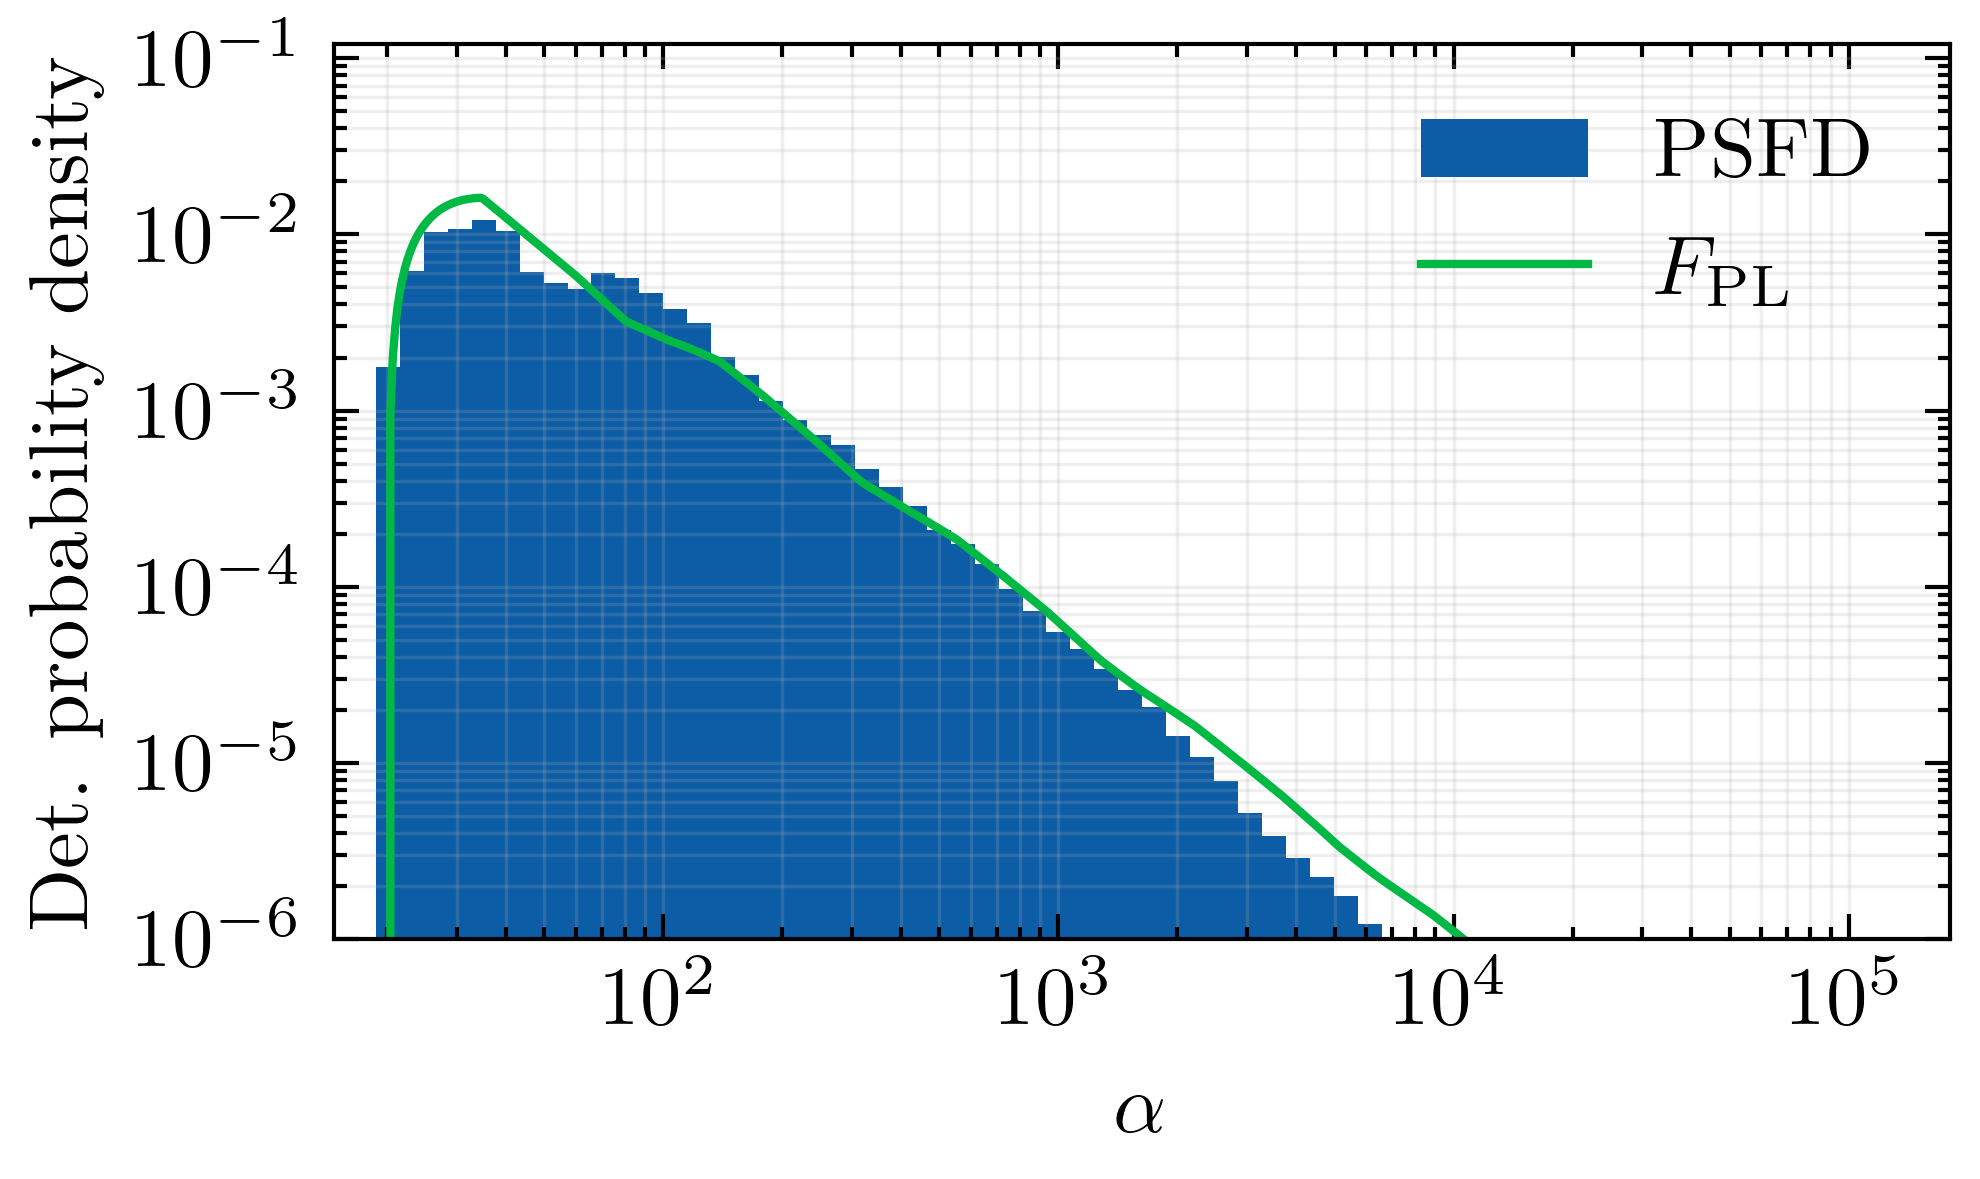

In [ ]:
power_law_fit = PowerLawFittingFunction(dp, LAD_min=0)
power_law_mle_model: GenericLikelihoodModelResults = power_law_fit.MLE_fit(
    optimize_params = PowerLawFitParams(q=1.63, g=1.8),
    verbose = False
)

counts, bins, _ = plt.hist(power_law_fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = "PSFD")
power_law_fit_params = PowerLawFitParams(*power_law_mle_model.params)
plt.plot(alphas, power_law_fit.F_norm(alphas, power_law_fit_params), label = r"$F_{\text{PL}}$")

plt.ylim(1e-6, counts.max() * 10)
plt.xlim(power_law_fit.plot_range[0] * 0.7, power_law_fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("PowerLaw_best_fit.png")
plt.show()

Optimization terminated successfully.
         Current function value: 6.154568
         Iterations: 16
         Function evaluations: 32


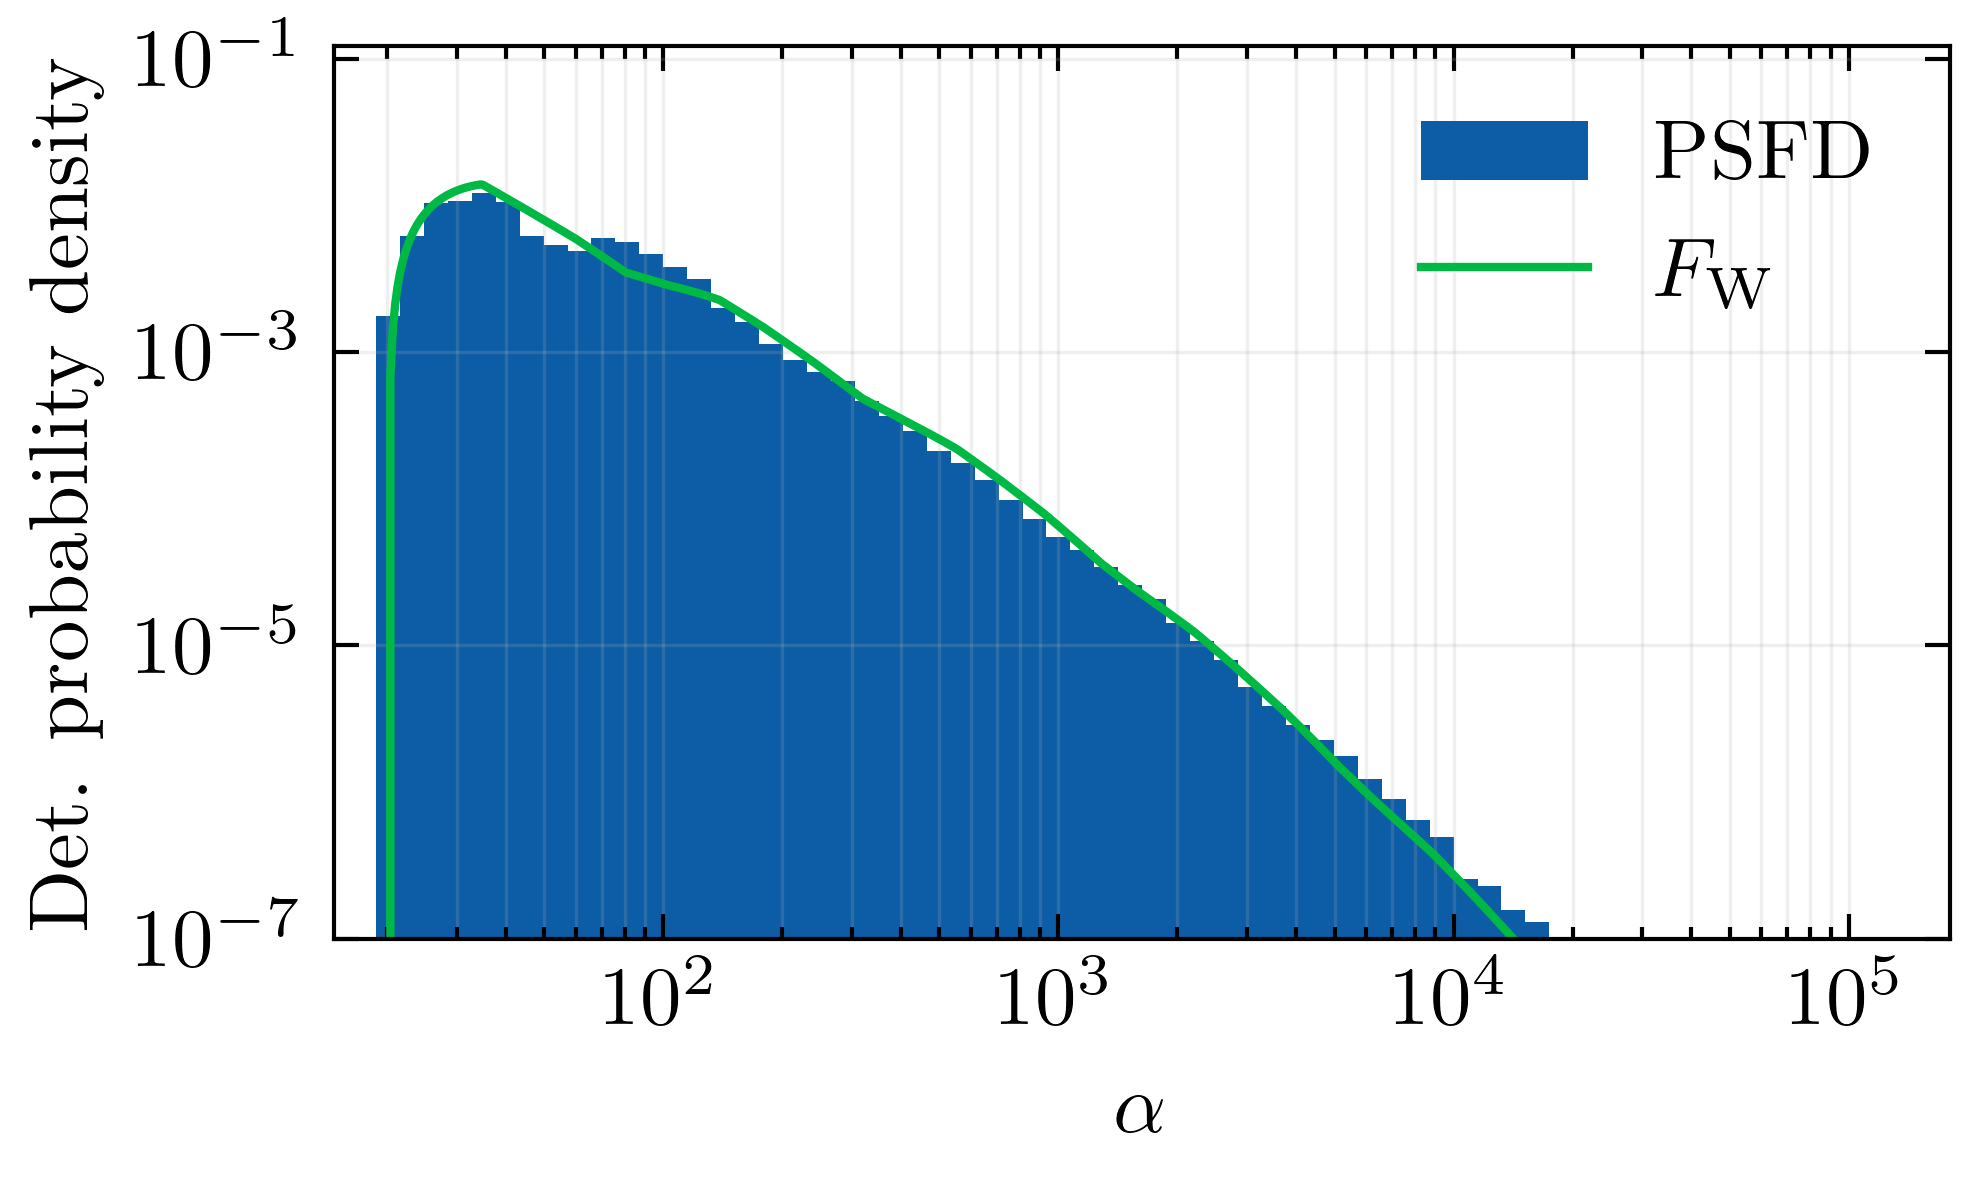

In [6]:
weibull_fit = WeibullFittingFunction(dp, LAD_min=0)

weibull_mle_model: GenericLikelihoodModelResults = weibull_fit.MLE_fit(
    optimize_params = WeibullFitParams(lambda_ = 0.0002, k = 0.2053),
    verbose = False
)

counts, bins, _ = plt.hist(weibull_fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = "PSFD")
weibull_fit_params = WeibullFitParams(*weibull_mle_model.params)
plt.plot(alphas, weibull_fit.F_norm(alphas, weibull_fit_params), label = r"$F_{\text{W}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(weibull_fit.plot_range[0] * 0.7, weibull_fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("Weibull_best_fit.png")
plt.show()

Running iteration with params [-2.30258509  2.        ]
Running iteration with params [-2.41771435  2.        ]
Running iteration with params [-2.30258509  2.1       ]
Running iteration with params [-2.41771435  1.9       ]
Running iteration with params [-2.47527897  1.8       ]
Running iteration with params [-2.59040823  1.8       ]
Running iteration with params [-2.7343198  1.7      ]
Running iteration with params [-2.79188443  1.5       ]
Running iteration with params [-2.97896946  1.25      ]
Running iteration with params [-3.05092525  1.4       ]
Running iteration with params [-2.90701368  1.5       ]
Running iteration with params [-2.96457831  1.3       ]
Running iteration with params [-2.79188443  1.6       ]
Running iteration with params [-2.90701368  1.4       ]
Running iteration with params [-2.82066674  1.55      ]
Running iteration with params [-2.93579599  1.55      ]
Running iteration with params [-3.00775178  1.575     ]
Running iteration with params [-3.09409872  1.525 

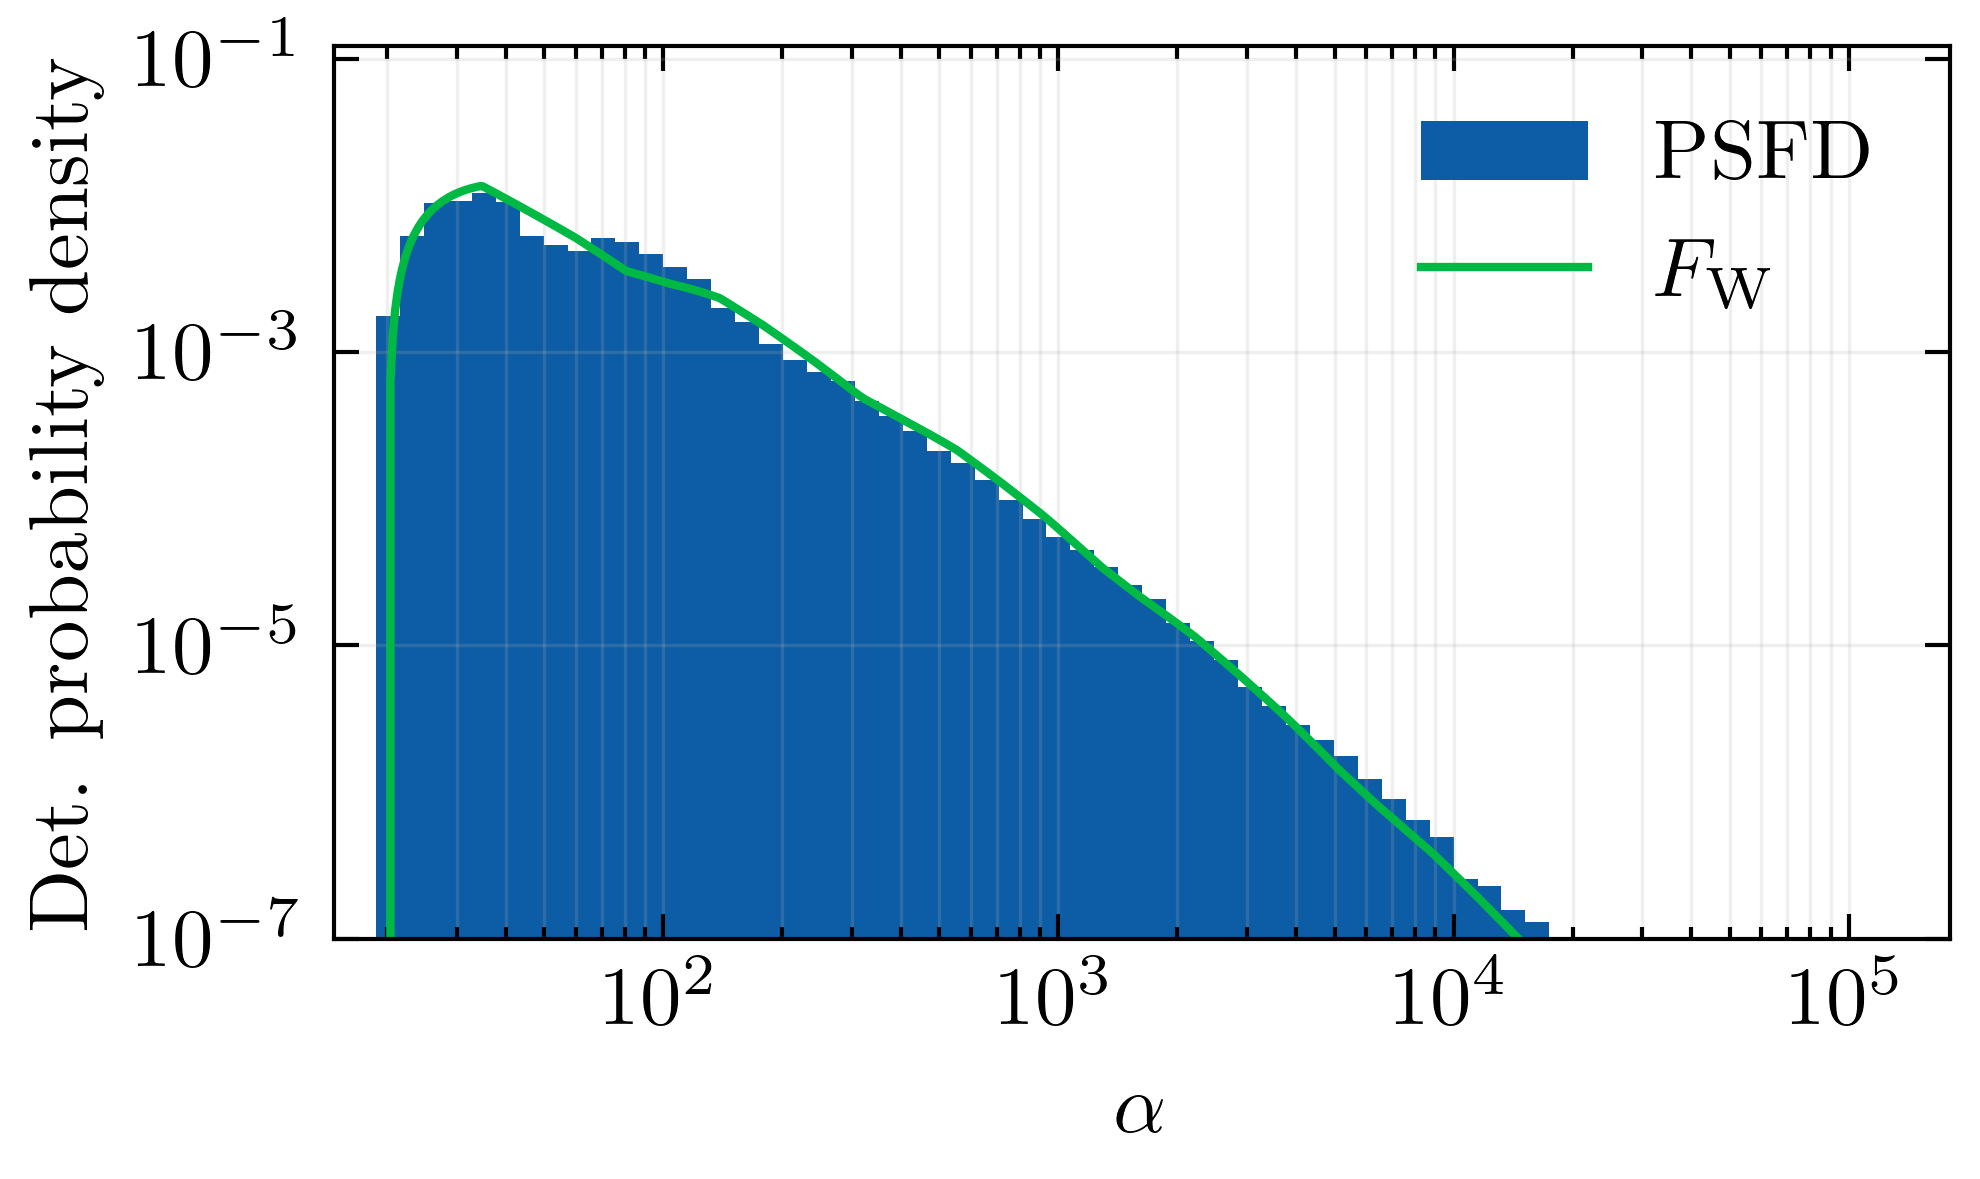

In [ ]:
LogNormal_fit = LogNormalFittingFunction(dp, LAD_min=0)

LogNormal_mle_model: GenericLikelihoodModelResults = LogNormal_fit.MLE_fit(
    optimize_params = LogNormalFitParams(mu=-2.302585093, sigma=2),
    verbose = False
)

counts, bins, _ = plt.hist(LogNormal_fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = "PSFD")
LogNormal_fit_params = LogNormalFitParams(*LogNormal_mle_model.params)
plt.plot(alphas, LogNormal_fit.F_norm(alphas, LogNormal_fit_params), label = r"$F_{\text{W}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(LogNormal_fit.plot_range[0] * 0.7, LogNormal_fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("LogNormal_best_fit.png")
plt.show()

In [ ]:
from boulder_statistics.analysis.fit_params import log_normal_fit_params

pl.DataFrame({
    "Model" : np.ndarray(["PowerLaw", "Weibull", "LogNormal"]),
    "AIC" : np.ndarray([power_law_mle_model.aic, weibull_mle_model.aic, LogNormal_mle_model.aic])
})

min_AIC = min(power_law_mle_model.aic, weibull_mle_model.aic)

L_power_law = np.exp(- 0.5 * (power_law_mle_model.aic - min_AIC))
L_weibull = np.exp(- 0.5 * (weibull_mle_model.aic - min_AIC))
L_log_normal = np.exp(- 0.5 * (LogNormal_mle_model.aic - min_AIC))

L_total = L_power_law + L_weibull + L_log_normal

w_power_law = L_power_law / (L_power_law + L_weibull)
w_weibull = L_weibull / (L_power_law + L_weibull)

print(f"w_power_law {w_power_law} and w_weibull {w_weibull}")
print(f"e^{0.5 * (power_law_mle_model.aic - weibull_mle_model.aic)} times more likely")

w_power_law 0.0 and w_weibull 1.0
e^10588.445870735217 times more likely
